In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importamos librerias

In [ ]:
import json
import random
import shutil
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from joblib import Memory
from PIL import Image, UnidentifiedImageError

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline

Ajustes generales: rutas, division de carpetas, variables globales...

In [ ]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)

# ==========================================================
# Dataset original
# ==========================================================

RUTA_DATASET = Path(
    "/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset"
)

CLASES = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

EXTENSIONES_VALIDAS = {
    ".png",
    ".jpg",
    ".jpeg"
}


# Cada imagen se convierte en 64 x 64 = 4096 características.
TAMANO_IMAGEN_RF = (64, 64)

# PCA fijo para mantener la comparación con el modelo original.
NUMERO_COMPONENTES_PCA = 150

PORCENTAJE_ENTRENAMIENTO = 0.70
PORCENTAJE_VALIDACION = 0.15
PORCENTAJE_TEST = 0.15

# None = utilizar todas las imágenes disponibles.
MAX_IMAGENES_POR_CLASE = None


# Optimización mediante GridSearchCV



MODO_RAPIDO = True

NUMERO_FOLDS_CV = 3


N_JOBS_BUSQUEDA = 2

if MODO_RAPIDO:
    CUADRICULA_HIPERPARAMETROS = {
        "rf__n_estimators": [
            250
        ],

        "rf__max_depth": [
            None,
            25
        ],

        "rf__class_weight": [
            "balanced_subsample"
        ],

        "rf__min_samples_split": [
            2
        ],

        "rf__min_samples_leaf": [
            1
        ],

        "rf__max_features": [
            "sqrt"
        ],

        "rf__bootstrap": [
            True
        ]
    }

else:
    CUADRICULA_HIPERPARAMETROS = {
        "rf__n_estimators": [
            250,
            400
        ],

        "rf__max_depth": [
            None,
            25
        ],

        "rf__class_weight": [
            None,
            "balanced_subsample"
        ],

        "rf__min_samples_split": [
            2
        ],

        "rf__min_samples_leaf": [
            1
        ],

        "rf__max_features": [
            "sqrt"
        ],

        "rf__bootstrap": [
            True
        ]
    }


# Rutas de guardado


RUTA_CARPETA_MODELOS_RF = Path(
    "/content/drive/MyDrive/TFG/modelos random forest"
)

RUTA_CARPETA_MODELOS_RF.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_PIPELINE_RF_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS_RF
    / "pipeline_random_forest_pca_gridsearch.joblib"
)

RUTA_MODELO_RF_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS_RF
    / "random_forest_3_clases_gridsearch.joblib"
)

RUTA_PCA_RF_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS_RF
    / "pca_random_forest_3_clases_gridsearch.joblib"
)

RUTA_RESULTADOS_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS_RF
    / "resultados_gridsearch_random_forest.csv"
)

RUTA_RESUMEN_MODELO = (
    RUTA_CARPETA_MODELOS_RF
    / "resumen_random_forest_gridsearch.txt"
)

RUTA_PARTICIONES = (
    RUTA_CARPETA_MODELOS_RF
    / "particiones_random_forest_gridsearch.csv"
)

RUTA_IMAGENES_INVALIDAS = (
    RUTA_CARPETA_MODELOS_RF
    / "imagenes_invalidas_random_forest_gridsearch.csv"
)

RUTA_MATRIZ_CONFUSION = (
    RUTA_CARPETA_MODELOS_RF
    / "matriz_confusion_random_forest_gridsearch.csv"
)

# Caché temporal local de Colab.
RUTA_CACHE_PIPELINE = Path(
    "/content/cache_pipeline_random_forest_gridsearch"
)

LIMPIAR_CACHE_AL_INICIAR = True



NUMERO_COMBINACIONES = len(
    list(
        ParameterGrid(
            CUADRICULA_HIPERPARAMETROS
        )
    )
)

NUMERO_AJUSTES_APROXIMADO = (
    NUMERO_COMBINACIONES
    * NUMERO_FOLDS_CV
    + 1
)

print("Dataset:")
print(RUTA_DATASET)

print("\nClases:")
print(CLASES)

print("\nModo rápido:")
print(MODO_RAPIDO)

print("\nComponentes PCA:")
print(NUMERO_COMPONENTES_PCA)

print("\nNúmero de combinaciones GridSearchCV:")
print(NUMERO_COMBINACIONES)

print("\nNúmero de folds:")
print(NUMERO_FOLDS_CV)

print("\nNúmero aproximado de ajustes:")
print(NUMERO_AJUSTES_APROXIMADO)

print("\nCarpeta de guardado:")
print(RUTA_CARPETA_MODELOS_RF)

Dataset:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Clases:
['COVID', 'Normal', 'Viral Pneumonia']

Modo rápido:
True

Componentes PCA:
150

Número de combinaciones GridSearchCV:
2

Número de folds:
3

Número aproximado de ajustes:
7

Carpeta de guardado:
/content/drive/MyDrive/TFG/modelos random forest


Realizamos comprobaciones de dataset y su ruta

In [ ]:
if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f"No existe la carpeta del dataset: {RUTA_DATASET}"
    )

print("Contenido de la carpeta principal:")

for elemento in sorted(RUTA_DATASET.iterdir()):
    print("-", elemento.name)

print("\nConteo inicial de imágenes por clase:")

for nombre_clase in CLASES:
    ruta_clase = RUTA_DATASET / nombre_clase
    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    if not ruta_busqueda.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de imágenes para la clase: {nombre_clase}"
        )

    imagenes = [
        archivo
        for archivo in ruta_busqueda.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower() in EXTENSIONES_VALIDAS
            and "mask" not in str(archivo).lower()
            and "masks" not in str(archivo).lower()
        )
    ]

    print(nombre_clase, ":", len(imagenes))

Contenido de la carpeta principal:
- COVID
- COVID.metadata.xlsx
- Lung_Opacity
- Lung_Opacity.metadata.xlsx
- Normal
- Normal.metadata.xlsx
- README.md.txt
- Viral Pneumonia
- Viral Pneumonia.metadata.xlsx

Conteo inicial de imágenes por clase:
COVID : 3616
Normal : 10192
Viral Pneumonia : 1345


Funciones auxiliares, sirven para hacer las listas de las clases de imagenbes en el dataset y para vectorizar las imagenes para que el algoritmo las pueda procesar

In [ ]:
try:
    REMUESTREO_BILINEAL = Image.Resampling.BILINEAR
except AttributeError:
    REMUESTREO_BILINEAL = Image.BILINEAR


def listar_imagenes_clase(ruta_clase: Path):
    """
    Busca imágenes de una clase.

    Si existe una subcarpeta images, utiliza esa carpeta.
    Excluye posibles máscaras.
    """

    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    imagenes = [
        archivo
        for archivo in ruta_busqueda.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower() in EXTENSIONES_VALIDAS
            and "mask" not in str(archivo).lower()
            and "masks" not in str(archivo).lower()
        )
    ]

    return sorted(imagenes)


def cargar_imagen_como_vector(ruta_imagen: Path):
    """
    Convierte una radiografía en un vector para Random Forest.

    Pasos:
    1. Escala de grises.
    2. Resize a 64 x 64.
    3. Normalización de píxeles al rango 0-1.
    4. Conversión en vector plano de 4096 características.
    """

    with Image.open(ruta_imagen) as imagen:
        imagen = imagen.convert("L")

        imagen = imagen.resize(
            TAMANO_IMAGEN_RF,
            REMUESTREO_BILINEAL
        )

        array_imagen = np.array(
            imagen,
            dtype=np.float32
        )

    array_imagen = array_imagen / 255.0

    vector_imagen = array_imagen.flatten()

    return vector_imagen


def cargar_conjunto(rutas, etiquetas, nombre_conjunto):
    """
    Carga una partición completa en memoria.

    Si una imagen está dañada, registra el problema y continúa.
    """

    vectores = []
    etiquetas_validas = []
    rutas_validas = []
    errores = []

    total = len(rutas)

    for indice, (ruta, etiqueta) in enumerate(
        zip(rutas, etiquetas),
        start=1
    ):
        try:
            vector = cargar_imagen_como_vector(
                Path(ruta)
            )

            vectores.append(vector)
            etiquetas_validas.append(int(etiqueta))
            rutas_validas.append(str(ruta))

        except (
            OSError,
            ValueError,
            UnidentifiedImageError
        ) as error:
            errores.append(
                {
                    "ruta": str(ruta),
                    "error": str(error)
                }
            )

        if indice % 500 == 0 or indice == total:
            print(
                f"{nombre_conjunto}: "
                f"{indice}/{total} imágenes procesadas",
                flush=True
            )

    X = np.asarray(
        vectores,
        dtype=np.float32
    )

    y = np.asarray(
        etiquetas_validas,
        dtype=np.int64
    )

    return X, y, rutas_validas, errores


def mostrar_distribucion(etiquetas, nombre_conjunto):
    print(f"\nDistribución de {nombre_conjunto}:")

    for indice_clase, nombre_clase in enumerate(CLASES):
        cantidad = int(
            np.sum(
                etiquetas == indice_clase
            )
        )

        print(
            f"- {nombre_clase}: {cantidad}"
        )

Crea la ruta para las imagenes y las etiquetas para cada imagen vectorizada.

In [ ]:
rutas_imagenes = []
etiquetas = []

for indice_clase, nombre_clase in enumerate(CLASES):
    ruta_clase = RUTA_DATASET / nombre_clase

    if not ruta_clase.exists():
        raise FileNotFoundError(
            f"No existe la carpeta de clase: {ruta_clase}"
        )

    imagenes_clase = listar_imagenes_clase(
        ruta_clase
    )

    if len(imagenes_clase) == 0:
        raise ValueError(
            f"No se encontraron imágenes para la clase: {nombre_clase}"
        )

    if (
        MAX_IMAGENES_POR_CLASE is not None
        and len(imagenes_clase) > MAX_IMAGENES_POR_CLASE
    ):
        generador_clase = random.Random(
            SEMILLA + indice_clase
        )

        generador_clase.shuffle(
            imagenes_clase
        )

        imagenes_clase = imagenes_clase[
            :MAX_IMAGENES_POR_CLASE
        ]

    for ruta_imagen in imagenes_clase:
        rutas_imagenes.append(
            str(ruta_imagen)
        )

        etiquetas.append(
            indice_clase
        )

    print(
        nombre_clase,
        ":",
        len(imagenes_clase)
    )


rutas_imagenes = np.asarray(
    rutas_imagenes,
    dtype=object
)

etiquetas = np.asarray(
    etiquetas,
    dtype=np.int64
)


print("\nTotal de imágenes:")
print(len(rutas_imagenes))

COVID : 3616
Normal : 10192
Viral Pneumonia : 1345

Total de imágenes:
15153


Se hace la division entre test validacion y entrenamiento de las imagenes vectorizadas

In [ ]:
rutas_entrenamiento, rutas_temporales, y_entrenamiento, y_temporales = train_test_split(
    rutas_imagenes,
    etiquetas,
    test_size=(
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    ),
    random_state=SEMILLA,
    shuffle=True,
    stratify=etiquetas
)


proporcion_test_sobre_temporal = (
    PORCENTAJE_TEST
    / (
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    )
)


rutas_validacion, rutas_test, y_validacion, y_test = train_test_split(
    rutas_temporales,
    y_temporales,
    test_size=proporcion_test_sobre_temporal,
    random_state=SEMILLA,
    shuffle=True,
    stratify=y_temporales
)


print("Tamaño de entrenamiento:")
print(len(rutas_entrenamiento))

print("\nTamaño de validación:")
print(len(rutas_validacion))

print("\nTamaño de test:")
print(len(rutas_test))


mostrar_distribucion(
    y_entrenamiento,
    "entrenamiento"
)

mostrar_distribucion(
    y_validacion,
    "validación"
)

mostrar_distribucion(
    y_test,
    "test"
)


df_particiones = pd.DataFrame(
    {
        "ruta": np.concatenate(
            [
                rutas_entrenamiento,
                rutas_validacion,
                rutas_test
            ]
        ),

        "etiqueta": np.concatenate(
            [
                y_entrenamiento,
                y_validacion,
                y_test
            ]
        ),

        "particion": (
            ["entrenamiento"] * len(rutas_entrenamiento)
            + ["validacion"] * len(rutas_validacion)
            + ["test"] * len(rutas_test)
        )
    }
)

df_particiones["clase"] = df_particiones[
    "etiqueta"
].apply(
    lambda indice: CLASES[int(indice)]
)

df_particiones.to_csv(
    RUTA_PARTICIONES,
    index=False
)


print("\nParticiones guardadas en:")
print(RUTA_PARTICIONES)

Tamaño de entrenamiento:
10607

Tamaño de validación:
2273

Tamaño de test:
2273

Distribución de entrenamiento:
- COVID: 2531
- Normal: 7134
- Viral Pneumonia: 942

Distribución de validación:
- COVID: 542
- Normal: 1529
- Viral Pneumonia: 202

Distribución de test:
- COVID: 543
- Normal: 1529
- Viral Pneumonia: 201

Particiones guardadas en:
/content/drive/MyDrive/TFG/modelos random forest/particiones_random_forest_gridsearch.csv


Se vectorizan en esta celda las imagenes para que puedan ser procesadas por el modelo, pues este modelo no permite procesar imagenes.

In [ ]:
inicio_carga = time.time()

X_entrenamiento, y_entrenamiento, rutas_entrenamiento_validas, errores_entrenamiento = cargar_conjunto(
    rutas_entrenamiento,
    y_entrenamiento,
    "Entrenamiento"
)

X_validacion, y_validacion, rutas_validacion_validas, errores_validacion = cargar_conjunto(
    rutas_validacion,
    y_validacion,
    "Validación"
)

X_test, y_test, rutas_test_validas, errores_test = cargar_conjunto(
    rutas_test,
    y_test,
    "Test"
)


errores_totales = (
    errores_entrenamiento
    + errores_validacion
    + errores_test
)


df_errores = pd.DataFrame(
    errores_totales
)

df_errores.to_csv(
    RUTA_IMAGENES_INVALIDAS,
    index=False
)


print("\nCarga terminada.")

print(
    "Tiempo total:",
    f"{(time.time() - inicio_carga) / 60:.2f} minutos"
)

print("\nForma de X_entrenamiento:")
print(X_entrenamiento.shape)

print("\nForma de X_validacion:")
print(X_validacion.shape)

print("\nForma de X_test:")
print(X_test.shape)

print("\nNúmero de imágenes inválidas:")
print(len(errores_totales))

Entrenamiento: 500/10607 imágenes procesadas
Entrenamiento: 1000/10607 imágenes procesadas
Entrenamiento: 1500/10607 imágenes procesadas
Entrenamiento: 2000/10607 imágenes procesadas
Entrenamiento: 2500/10607 imágenes procesadas
Entrenamiento: 3000/10607 imágenes procesadas
Entrenamiento: 3500/10607 imágenes procesadas
Entrenamiento: 4000/10607 imágenes procesadas
Entrenamiento: 4500/10607 imágenes procesadas
Entrenamiento: 5000/10607 imágenes procesadas
Entrenamiento: 5500/10607 imágenes procesadas
Entrenamiento: 6000/10607 imágenes procesadas
Entrenamiento: 6500/10607 imágenes procesadas
Entrenamiento: 7000/10607 imágenes procesadas
Entrenamiento: 7500/10607 imágenes procesadas
Entrenamiento: 8000/10607 imágenes procesadas
Entrenamiento: 8500/10607 imágenes procesadas
Entrenamiento: 9000/10607 imágenes procesadas
Entrenamiento: 9500/10607 imágenes procesadas
Entrenamiento: 10000/10607 imágenes procesadas
Entrenamiento: 10500/10607 imágenes procesadas
Entrenamiento: 10607/10607 imágen

Se hace una comprobacion de que lña distribucion de los datos es limpia

In [ ]:
print("COMPROBACIÓN DE DATOS")
print("=" * 80)

print("\nEntrenamiento:")
print("X:", X_entrenamiento.shape)
print("y:", y_entrenamiento.shape)

print("\nValidación:")
print("X:", X_validacion.shape)
print("y:", y_validacion.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

print("\nCaracterísticas iniciales por imagen:")
print(X_entrenamiento.shape[1])

mostrar_distribucion(
    y_entrenamiento,
    "entrenamiento cargado"
)

mostrar_distribucion(
    y_validacion,
    "validación cargada"
)

mostrar_distribucion(
    y_test,
    "test cargado"
)

memoria_mb = (
    X_entrenamiento.nbytes
    + X_validacion.nbytes
    + X_test.nbytes
) / (1024 ** 2)

print("\nMemoria aproximada ocupada:")
print(f"{memoria_mb:.2f} MB")

COMPROBACIÓN DE DATOS

Entrenamiento:
X: (10607, 4096)
y: (10607,)

Validación:
X: (2273, 4096)
y: (2273,)

Test:
X: (2273, 4096)
y: (2273,)

Características iniciales por imagen:
4096

Distribución de entrenamiento cargado:
- COVID: 2531
- Normal: 7134
- Viral Pneumonia: 942

Distribución de validación cargada:
- COVID: 542
- Normal: 1529
- Viral Pneumonia: 202

Distribución de test cargado:
- COVID: 543
- Normal: 1529
- Viral Pneumonia: 201

Memoria aproximada ocupada:
236.77 MB


Aplicamos PCA para el conjunto de las imagenes vectorizadas

In [ ]:
if LIMPIAR_CACHE_AL_INICIAR and RUTA_CACHE_PIPELINE.exists():
    shutil.rmtree(
        RUTA_CACHE_PIPELINE
    )

RUTA_CACHE_PIPELINE.mkdir(
    parents=True,
    exist_ok=True
)

memoria_pipeline = Memory(
    location=str(RUTA_CACHE_PIPELINE),
    verbose=0
)


pipeline_rf = Pipeline(
    steps=[
        (
            "pca",
            PCA(
                n_components=NUMERO_COMPONENTES_PCA,
                svd_solver="randomized",
                random_state=SEMILLA
            )
        ),

        (
            "rf",
            RandomForestClassifier(
                random_state=SEMILLA,

                n_jobs=1
            )
        )
    ],

    memory=memoria_pipeline
)


validacion_cruzada = StratifiedKFold(
    n_splits=NUMERO_FOLDS_CV,
    shuffle=True,
    random_state=SEMILLA
)


print("Pipeline creado:")
print(pipeline_rf)

print("\nValidación cruzada:")
print(validacion_cruzada)

print("\nCuadrícula:")
print(CUADRICULA_HIPERPARAMETROS)

print("\nNúmero de combinaciones:")
print(NUMERO_COMBINACIONES)

print("\nNúmero aproximado de ajustes:")
print(NUMERO_AJUSTES_APROXIMADO)
print(pipeline_rf)

Pipeline creado:
Pipeline(memory=Memory(location=/content/cache_pipeline_random_forest_gridsearch/joblib),
         steps=[('pca',
                 PCA(n_components=150, random_state=42,
                     svd_solver='randomized')),
                ('rf', RandomForestClassifier(n_jobs=1, random_state=42))])

Validación cruzada:
StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

Cuadrícula:
{'rf__n_estimators': [250], 'rf__max_depth': [None, 25], 'rf__class_weight': ['balanced_subsample'], 'rf__min_samples_split': [2], 'rf__min_samples_leaf': [1], 'rf__max_features': ['sqrt'], 'rf__bootstrap': [True]}

Número de combinaciones:
2

Número aproximado de ajustes:
7
Pipeline(memory=Memory(location=/content/cache_pipeline_random_forest_gridsearch/joblib),
         steps=[('pca',
                 PCA(n_components=150, random_state=42,
                     svd_solver='randomized')),
                ('rf', RandomForestClassifier(n_jobs=1, random_state=42))])


Entrenar modelo y optimizacion de hiperparametros

In [ ]:
busqueda_grid = GridSearchCV(
    estimator=pipeline_rf,

    param_grid=CUADRICULA_HIPERPARAMETROS,

    # Priorizamos el rendimiento equilibrado entre clases.
    scoring="f1_macro",

    cv=validacion_cruzada,

    # Al finalizar, reentrena la mejor combinación
    # con todo X_entrenamiento.
    refit=True,

    n_jobs=N_JOBS_BUSQUEDA,

    # Limita la cantidad de trabajos preparados simultáneamente.
    pre_dispatch=N_JOBS_BUSQUEDA,

    verbose=2,

    return_train_score=True,

    error_score="raise"
)


print("INICIANDO GRID SEARCH")
print("=" * 80)

print("\nCombinaciones:")
print(NUMERO_COMBINACIONES)

print("\nFolds por combinación:")
print(NUMERO_FOLDS_CV)

print("\nAjustes aproximados:")
print(NUMERO_AJUSTES_APROXIMADO)


inicio_gridsearch = time.time()


busqueda_grid.fit(
    X_entrenamiento,
    y_entrenamiento
)


tiempo_gridsearch = (
    time.time()
    - inicio_gridsearch
)


print("\nGRID SEARCH TERMINADO")
print("=" * 80)

print("\nTiempo total:")
print(f"{tiempo_gridsearch / 60:.2f} minutos")

print("\nMejor macro F1 medio en validación cruzada:")
print(busqueda_grid.best_score_)

print("\nMejores hiperparámetros:")
print(busqueda_grid.best_params_)

INICIANDO GRID SEARCH

Combinaciones:
2

Folds por combinación:
3

Ajustes aproximados:
7
Fitting 3 folds for each of 2 candidates, totalling 6 fits

GRID SEARCH TERMINADO

Tiempo total:
2.49 minutos

Mejor macro F1 medio en validación cruzada:
0.6370763372288398

Mejores hiperparámetros:
{'rf__bootstrap': True, 'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 25, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 250}


Guardar resultados de GridSearchCV

In [ ]:
df_resultados_gridsearch = pd.DataFrame(
    busqueda_grid.cv_results_
)

df_resultados_gridsearch = df_resultados_gridsearch.sort_values(
    by="rank_test_score"
)

df_resultados_gridsearch.to_csv(
    RUTA_RESULTADOS_GRIDSEARCH,
    index=False
)


print("Resultados de GridSearchCV guardados en:")
print(RUTA_RESULTADOS_GRIDSEARCH)

print("\nMejores configuraciones:")

display(
    df_resultados_gridsearch[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
)

Resultados de GridSearchCV guardados en:
/content/drive/MyDrive/TFG/modelos random forest/resultados_gridsearch_random_forest.csv

Mejores configuraciones:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
1,1,0.637076,0.014708,1.0,"{'rf__bootstrap': True, 'rf__class_weight': 'b..."
0,2,0.623542,0.013038,1.0,"{'rf__bootstrap': True, 'rf__class_weight': 'b..."


Recupera el mejor modelo

In [ ]:
modelo_rf_gridsearch = (
    busqueda_grid.best_estimator_
)

mejor_score_cv = (
    busqueda_grid.best_score_
)

mejores_hiperparametros = (
    busqueda_grid.best_params_
)


# Activamos paralelismo interno para predicciones posteriores.
modelo_rf_gridsearch.set_params(
    rf__n_jobs=-1
)


print("Mejor modelo recuperado.")

print("\nMejor macro F1 medio en validación cruzada:")
print(mejor_score_cv)

print("\nHiperparámetros seleccionados:")
print(mejores_hiperparametros)

Mejor modelo recuperado.

Mejor macro F1 medio en validación cruzada:
0.6370763372288398

Hiperparámetros seleccionados:
{'rf__bootstrap': True, 'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 25, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 250}


Evalua el modelo con los datos de validacion

In [ ]:
predicciones_validacion = modelo_rf_gridsearch.predict(
    X_validacion
)


accuracy_validacion = accuracy_score(
    y_validacion,
    predicciones_validacion
)

macro_f1_validacion = f1_score(
    y_validacion,
    predicciones_validacion,
    average="macro"
)


reporte_validacion = classification_report(
    y_validacion,
    predicciones_validacion,

    labels=list(
        range(
            len(CLASES)
        )
    ),

    target_names=CLASES,

    digits=4,

    zero_division=0
)


print("=" * 80)
print("VALIDACIÓN")
print("=" * 80)

print("\nAccuracy:")
print(accuracy_validacion)

print("\nMacro F1:")
print(macro_f1_validacion)

print("\nReporte:")
print(reporte_validacion)

VALIDACIÓN

Accuracy:
0.7936647602287725

Macro F1:
0.6884395606903356

Reporte:
                 precision    recall  f1-score   support

          COVID     0.9581    0.2952    0.4513       542
         Normal     0.7676    0.9961    0.8671      1529
Viral Pneumonia     0.9918    0.5990    0.7469       202

       accuracy                         0.7937      2273
      macro avg     0.9058    0.6301    0.6884      2273
   weighted avg     0.8330    0.7937    0.7573      2273



Hacer lo mismo con las imagenes en test

In [ ]:
predicciones_test = modelo_rf_gridsearch.predict(
    X_test
)


accuracy_test = accuracy_score(
    y_test,
    predicciones_test
)

macro_f1_test = f1_score(
    y_test,
    predicciones_test,
    average="macro"
)


reporte_test = classification_report(
    y_test,
    predicciones_test,

    labels=list(
        range(
            len(CLASES)
        )
    ),

    target_names=CLASES,

    digits=4,

    zero_division=0
)


print("=" * 80)
print("TEST FINAL")
print("=" * 80)

print("\nAccuracy:")
print(accuracy_test)

print("\nMacro F1:")
print(macro_f1_test)

print("\nReporte:")
print(reporte_test)

TEST FINAL

Accuracy:
0.7923449186097669

Macro F1:
0.689085204617664

Reporte:
                 precision    recall  f1-score   support

          COVID     0.9554    0.2762    0.4286       543
         Normal     0.7666    0.9967    0.8666      1529
Viral Pneumonia     0.9922    0.6318    0.7720       201

       accuracy                         0.7923      2273
      macro avg     0.9047    0.6349    0.6891      2273
   weighted avg     0.8317    0.7923    0.7536      2273



Mostrar la reducción dimensional

In [ ]:
pca_final = modelo_rf_gridsearch.named_steps[
    "pca"
]

varianza_explicada = float(
    np.sum(
        pca_final.explained_variance_ratio_
    )
)


print("REDUCCIÓN DIMENSIONAL MEDIANTE PCA")
print("=" * 80)

print("\nCaracterísticas originales:")
print(
    TAMANO_IMAGEN_RF[0]
    * TAMANO_IMAGEN_RF[1]
)

print("\nComponentes PCA:")
print(
    pca_final.n_components_
)

print("\nVarianza explicada:")
print(
    varianza_explicada
)

print("\nVarianza explicada en porcentaje:")
print(
    f"{varianza_explicada * 100:.2f}%"
)

REDUCCIÓN DIMENSIONAL MEDIANTE PCA

Características originales:
4096

Componentes PCA:
150

Varianza explicada:
0.9637905955314636

Varianza explicada en porcentaje:
96.38%


Matriz de confusion

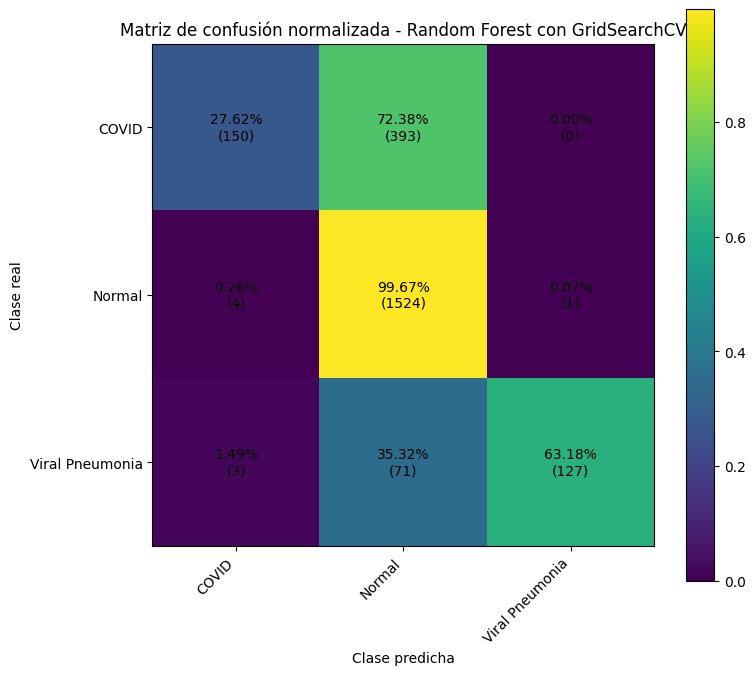

Matriz de confusión guardada en:
/content/drive/MyDrive/TFG/modelos random forest/matriz_confusion_random_forest_gridsearch.csv


In [ ]:
matriz_confusion = confusion_matrix(
    y_test,
    predicciones_test,

    labels=list(
        range(
            len(CLASES)
        )
    )
)


matriz_confusion_normalizada = (
    matriz_confusion.astype("float")
    / np.maximum(
        matriz_confusion.sum(
            axis=1
        )[:, np.newaxis],
        1
    )
)


df_matriz_confusion = pd.DataFrame(
    matriz_confusion,
    index=CLASES,
    columns=CLASES
)

df_matriz_confusion.to_csv(
    RUTA_MATRIZ_CONFUSION
)


figura, eje = plt.subplots(
    figsize=(8, 7)
)


imagen = eje.imshow(
    matriz_confusion_normalizada
)


eje.set_title(
    "Matriz de confusión normalizada - Random Forest con GridSearchCV"
)

eje.set_xlabel(
    "Clase predicha"
)

eje.set_ylabel(
    "Clase real"
)


eje.set_xticks(
    np.arange(
        len(CLASES)
    )
)

eje.set_yticks(
    np.arange(
        len(CLASES)
    )
)


eje.set_xticklabels(
    CLASES,
    rotation=45,
    ha="right"
)

eje.set_yticklabels(
    CLASES
)


for i in range(
    len(CLASES)
):
    for j in range(
        len(CLASES)
    ):
        porcentaje = (
            matriz_confusion_normalizada[i, j]
            * 100
        )

        valor_absoluto = (
            matriz_confusion[i, j]
        )

        texto = (
            f"{porcentaje:.2f}%\n"
            f"({valor_absoluto})"
        )

        eje.text(
            j,
            i,
            texto,
            ha="center",
            va="center"
        )


plt.colorbar(
    imagen
)

plt.tight_layout()

plt.show()


print("Matriz de confusión guardada en:")
print(RUTA_MATRIZ_CONFUSION)

In [ ]:
modelo_rf_final = modelo_rf_gridsearch.named_steps[
    "rf"
]

pca_final = modelo_rf_gridsearch.named_steps[
    "pca"
]


joblib.dump(
    modelo_rf_gridsearch,
    RUTA_PIPELINE_RF_GRIDSEARCH
)

joblib.dump(
    modelo_rf_final,
    RUTA_MODELO_RF_GRIDSEARCH
)

joblib.dump(
    pca_final,
    RUTA_PCA_RF_GRIDSEARCH
)


print("Pipeline completo guardado en:")
print(RUTA_PIPELINE_RF_GRIDSEARCH)

print("\nRandom Forest guardado en:")
print(RUTA_MODELO_RF_GRIDSEARCH)

print("\nPCA guardado en:")
print(RUTA_PCA_RF_GRIDSEARCH)

Pipeline completo guardado en:
/content/drive/MyDrive/TFG/modelos random forest/pipeline_random_forest_pca_gridsearch.joblib

Random Forest guardado en:
/content/drive/MyDrive/TFG/modelos random forest/random_forest_3_clases_gridsearch.joblib

PCA guardado en:
/content/drive/MyDrive/TFG/modelos random forest/pca_random_forest_3_clases_gridsearch.joblib


Guardamos el resumen

In [ ]:
with open(
    RUTA_RESUMEN_MODELO,
    "w",
    encoding="utf-8"
) as archivo:
    archivo.write(
        "RANDOM FOREST CON GRIDSEARCHCV - PRIMER DATASET - 3 CLASES\n"
    )

    archivo.write(
        "=" * 80
    )

    archivo.write(
        "\n\nClases:\n"
    )

    for clase in CLASES:
        archivo.write(
            f"- {clase}\n"
        )

    archivo.write(
        "\nTamaño de imagen:\n"
    )

    archivo.write(
        str(TAMANO_IMAGEN_RF)
    )

    archivo.write(
        "\n\nCaracterísticas iniciales:\n"
    )

    archivo.write(
        str(
            TAMANO_IMAGEN_RF[0]
            * TAMANO_IMAGEN_RF[1]
        )
    )

    archivo.write(
        "\n\nComponentes PCA:\n"
    )

    archivo.write(
        str(
            pca_final.n_components_
        )
    )

    archivo.write(
        "\n\nVarianza explicada por PCA:\n"
    )

    archivo.write(
        str(varianza_explicada)
    )

    archivo.write(
        "\n\nModo rápido:\n"
    )

    archivo.write(
        str(MODO_RAPIDO)
    )

    archivo.write(
        "\n\nNúmero de combinaciones GridSearchCV:\n"
    )

    archivo.write(
        str(NUMERO_COMBINACIONES)
    )

    archivo.write(
        "\n\nNúmero de folds:\n"
    )

    archivo.write(
        str(NUMERO_FOLDS_CV)
    )

    archivo.write(
        "\n\nNúmero aproximado de ajustes:\n"
    )

    archivo.write(
        str(NUMERO_AJUSTES_APROXIMADO)
    )

    archivo.write(
        "\n\nTiempo de GridSearchCV en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_gridsearch
            / 60
        )
    )

    archivo.write(
        "\n\nMejor macro F1 medio en validación cruzada:\n"
    )

    archivo.write(
        str(mejor_score_cv)
    )

    archivo.write(
        "\n\nMejores hiperparámetros:\n"
    )

    archivo.write(
        json.dumps(
            mejores_hiperparametros,
            indent=4,
            default=str
        )
    )

    archivo.write(
        "\n\nAccuracy validación:\n"
    )

    archivo.write(
        str(accuracy_validacion)
    )

    archivo.write(
        "\n\nMacro F1 validación:\n"
    )

    archivo.write(
        str(macro_f1_validacion)
    )

    archivo.write(
        "\n\nReporte validación:\n"
    )

    archivo.write(
        reporte_validacion
    )

    archivo.write(
        "\n\nAccuracy test:\n"
    )

    archivo.write(
        str(accuracy_test)
    )

    archivo.write(
        "\n\nMacro F1 test:\n"
    )

    archivo.write(
        str(macro_f1_test)
    )

    archivo.write(
        "\n\nReporte test:\n"
    )

    archivo.write(
        reporte_test
    )


print("Resumen guardado en:")
print(RUTA_RESUMEN_MODELO)

Resumen guardado en:
/content/drive/MyDrive/TFG/modelos random forest/resumen_random_forest_gridsearch.txt


Para actualizar las rutas

In [ ]:
print("Utiliza estas rutas en la app de Streamlit:")
print()

print("RUTA_MODELO_RF = Path(")
print(f'    "{RUTA_MODELO_RF_GRIDSEARCH}"')
print(")")

print()

print("RUTA_PCA_RF = Path(")
print(f'    "{RUTA_PCA_RF_GRIDSEARCH}"')
print(")")

Utiliza estas rutas en la app de Streamlit:

RUTA_MODELO_RF = Path(
    "/content/drive/MyDrive/TFG/modelos random forest/random_forest_3_clases_gridsearch.joblib"
)

RUTA_PCA_RF = Path(
    "/content/drive/MyDrive/TFG/modelos random forest/pca_random_forest_3_clases_gridsearch.joblib"
)
